This Notebook contains an example of Poisson Maximum Likelihood Estimation on proton data from a standard electrostatic analyser. First, we will import the relevant libraries and set the figure parameters.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.constants as sc
import cmocean
import lmfit # to perform the minimisation

mpl.rcParams['font.size'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['figure.figsize'] = [7, 7]

Now we will define the distribution we will need. We will simulate a double bi-Maxwellian proton distribution consisting of a core and a beam. Thus we need to define a bi-Maxwellian and a double bi-Maxwellian function. We also need to define a function of the double bi-Maxwellian in terms of the counts, $C$, detected by the instrument using the relation $C = \frac{2 G dt E^2 f}{m_p^2}$, where $G$ is the effective energy geometric factor, $dt$ is the acquisition time and $f$ is the VDF.

In [3]:
# Define a single and double bi-Maxwellian
def bi_Max(ux, uy, uz, n_var, v_x, v_y, v_z, v_th_par, v_th_perp):
    """
    Produces a VDF following a bi-Maxwellian distribution.

    Parameters
    ----------
    ux : array
        Velocity in the x (parallel) direction.
    uy : array
    
        Velocity in the y direction.
    uz : array
        Velocity in the z direction.
    n_var : float
        The plasma density in m^{m-3}.
    v_x : array
        Bulk velocity in the x (parallel) direction.
    v_y : array
        Bulk velocity in the y direction.
    v_z : array
        Bulk velocity in the z direction.
    v_th_par : float
        Thermal velocity in paraller (x) direction.
    v_th_perp : float
        Thermal velocity in perpendicular direction.

    Returns
    -------
    f : array
        The Velocity distribution function VDF.

    """

    vel_par = ux - v_x

    vy_perp = uy - v_y
    vz_perp = uz - v_z
    vel_perp = np.sqrt((vy_perp * vy_perp) + (vz_perp * vz_perp))

    denominator = (np.pi ** 1.5) * v_th_par * v_th_perp * v_th_perp
    term1 = n_var / denominator
    exponent = ((vel_par * vel_par) / (v_th_par * v_th_par)) + \
        ((vel_perp * vel_perp) / (v_th_perp * v_th_perp))

    f = term1 * np.exp(- exponent)

    return f


def double_bi_Max(ux, uy, uz, n_var1, vx1, vy1, vz1, v_th_par1, v_th_perp1, n_var2, vx2, vy2, vz2, v_th_par2, v_th_perp2):

    vel_par1 = ux - vx1

    vy_perp1 = uy - vy1
    vz_perp1 = uz - vz1
    vel_perp1 = np.sqrt((vy_perp1 * vy_perp1) + (vz_perp1 * vz_perp1))

    denominator1 = (np.pi ** 1.5) * v_th_par1 * v_th_perp1 * v_th_perp1
    term1 = n_var1 / denominator1
    exponent1 = ((vel_par1 * vel_par1) / (v_th_par1 * v_th_par1)) + \
        ((vel_perp1 * vel_perp1) / (v_th_perp1 * v_th_perp1))

    f1 = term1 * np.exp(- exponent1)

    vel_par2 = ux - vx2

    vy_perp2 = uy - vy2
    vz_perp2 = uz - vz2
    vel_perp2 = np.sqrt((vy_perp2 * vy_perp2) + (vz_perp2 * vz_perp2))

    denominator2 = (np.pi ** 1.5) * v_th_par2 * v_th_perp2 * v_th_perp2
    term2 = n_var2 / denominator2
    exponent2 = ((vel_par2 * vel_par2) / (v_th_par2 * v_th_par2)) + \
        ((vel_perp2 * vel_perp2) / (v_th_perp2 * v_th_perp2))

    f2 = term2 * np.exp(- exponent2)

    return f1 + f2

def counts_double_biMaxwellian(ux, uy, uz, n_var1, vx1, vy1, vz1, v_th_par1, v_th_perp1, n_var2, vx2, vy2, vz2, v_th_par2, v_th_perp2, G, dt):

    vel_mag = np.linalg.norm(np.array([ux, uy, uz]), axis=0)
    E = 0.5 * sc.m_p * vel_mag * vel_mag

    vdf = double_bi_Max(ux, uy, uz, n_var1, vx1, vy1, vz1, v_th_par1, v_th_perp1, n_var2, vx2, vy2, vz2, v_th_par2, v_th_perp2)

    counts = 2 * G * dt * (E**2) * vdf / (sc.m_p**2) 

    return counts


Now let's simulate a double bi-Maxwellian.

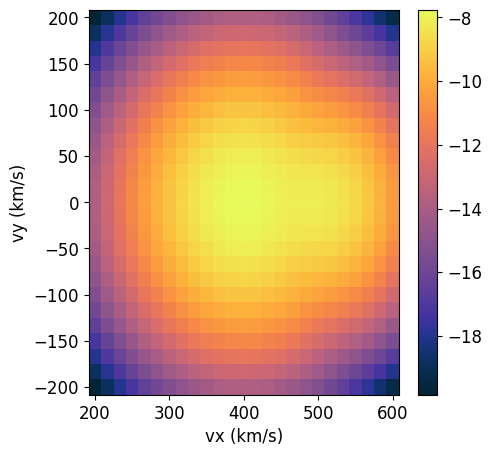

In [4]:
# Create grid
grid_size = 25
vx = np.linspace( 200e3, 600e3, grid_size) # in m/s
vy = np.linspace(-200e3, 200e3, grid_size) # in m/s
vz = np.linspace(-200e3, 200e3, grid_size) # in m/s

vx_grid, vy_grid, vz_grid = np.meshgrid(vx, vy, vz, indexing='ij')
energy = 0.5 * sc.m_p * (np.linalg.norm([vx_grid, vy_grid, vz_grid], axis = 0)**2) /sc.e # in eV
"""
Parameters for bi-Maxwellian
"""
# CORE
n_in1 = 15e6  # in m^-3
T_par_in1 = 15  # in eV
T_perp_in1 = 15  # in eV
v_th_par_in1 = np.sqrt(2 * T_par_in1 * sc.e / sc.m_p) # in m/s
v_th_perp_in1 = np.sqrt(2 * T_perp_in1 * sc.e / sc.m_p) # in m/s
vx_bulk_in1 = 400e3 # in m/s
vy_bulk_in1 = 0.0 # in m/s
vz_bulk_in1 = 0.0 # in m/s

# BEAM
n_in2 = 15e6 * 0.2  # in m^-3
T_par_in2 = 10  # in eV
T_perp_in2 = 10  # in eV
v_th_par_in2 = np.sqrt(2 * T_par_in2 * sc.e / sc.m_p) # in m/s
v_th_perp_in2 = np.sqrt(2 * T_perp_in2 * sc.e / sc.m_p) # in m/s
vx_bulk_in2 = 500e3 # in m/s
vy_bulk_in2 = 0e3 # in m/s
vz_bulk_in2 = 0e3 # in m/s

input_values = [n_in1, vx_bulk_in1, vy_bulk_in1, vz_bulk_in1, v_th_par_in1, v_th_perp_in1, n_in2, vx_bulk_in2,
                vy_bulk_in2, vz_bulk_in2, v_th_par_in2, v_th_perp_in2]

vdf = double_bi_Max(vx_grid, vy_grid, vz_grid, n_in1, vx_bulk_in1, vy_bulk_in1, vz_bulk_in1, v_th_par_in1, v_th_perp_in1, n_in2, vx_bulk_in2,
                    vy_bulk_in2, vz_bulk_in2, v_th_par_in2, v_th_perp_in2)

# Plot the distribution in the vx-vy plane 
fig, ax = plt.subplots(figsize = [5, 5])

c = ax.pcolormesh(vx_grid[:, :, int(grid_size / 2)]*1e-3, vy_grid[:, :, int(grid_size / 2)]*1e-3, np.log10(vdf[:, :, int(grid_size / 2)]), cmap=cmocean.cm.thermal)
ax.set_xlabel('vx (km/s)')
ax.set_ylabel('vy (km/s)')
plt.colorbar(c)
plt.show()

We shall set the peak Counts of the distribution to 100. To do this first we determine the $G$ factor needed to transform max $(f)$ into 100 Counts. Using this $G$ factor we can transform the entire VDF into Counts. Then we introduce Poisson error based on these Count values. Then we re-plot $f$, incorporating the Poisson error. 

Max Count check successful!


/tmp/ipykernel_2498841/129253841.py:35: RuntimeWarning: divide by zero encountered in log10
  c = ax.pcolormesh(vx_grid[:, :, int(grid_size/2)]*1e-3, vy_grid[:, :, int(grid_size/2)]*1e-3, np.log10(vdf_poisson[:, :, int(grid_size/2)]), cmap=cmocean.cm.thermal)


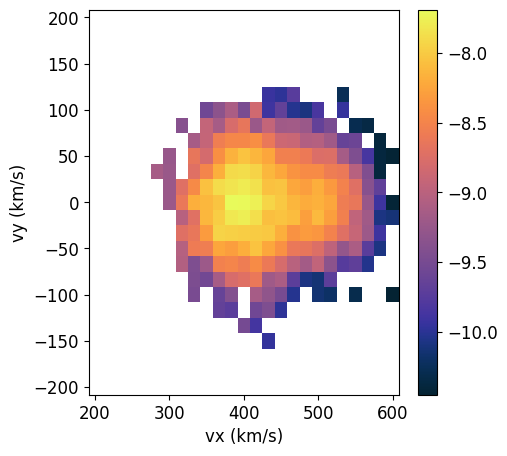

In [5]:
"""
Determine G needed to convert max VDF to max counts, C_max
"""
C_max = int(100)  # peak counts in distribution
max_c_ind = np.argmax(vdf * (energy**2))
vdf_max = vdf.flatten()[max_c_ind]  # max vdf value
dt = 1e-3  # acquisition time in seconds
E_vdf_max = energy.flatten()[max_c_ind] * sc.e  # in J
# G factor need to get max counts C_max
G = C_max * (sc.m_p**2) / (2 * dt * vdf_max * (E_vdf_max**2))

"""
Convert VDF to counts using determined G factor
"""
C = 2 * G * dt * ((energy*sc.e)**2) * vdf / (sc.m_p**2)

# Check G calculation is correct
C_check = np.max(C)

if C_max == round(C_check):
    print('Max Count check successful!')

else:
    raise Exception('Max Count check unsuccessful: C_max = ', C_max, ',  C_check = ', C_check)

"""
Add Poisson error to Counts and Convert back to VDF
"""
C_poisson = np.random.poisson(C)
vdf_poisson = C_poisson * sc.m_p * sc.m_p / (2 * dt * ((energy*sc.e)**2) * G)

# Plot VDF after adding poisson error
fig, ax = plt.subplots(figsize = [5, 5])

c = ax.pcolormesh(vx_grid[:, :, int(grid_size/2)]*1e-3, vy_grid[:, :, int(grid_size/2)]*1e-3, np.log10(vdf_poisson[:, :, int(grid_size/2)]), cmap=cmocean.cm.thermal)
ax.set_xlabel('vx (km/s)')
ax.set_ylabel('vy (km/s)')
plt.colorbar(c)
plt.show()

Let's also plot the simulated distribution in Counts.


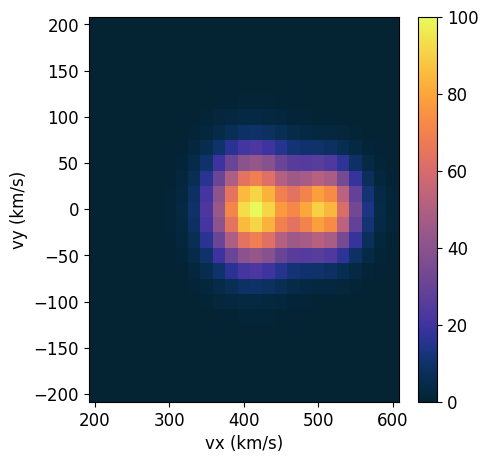

In [6]:
"""
Model function of bi-Maxwellian for counts
"""
C_fit_test = counts_double_biMaxwellian(vx_grid, vy_grid, vz_grid, n_in1, vx_bulk_in1, vy_bulk_in1, vz_bulk_in1, v_th_par_in1, v_th_perp_in1, n_in2, vx_bulk_in2,
                                        vy_bulk_in2, vz_bulk_in2, v_th_par_in2, v_th_perp_in2, G, dt)

fig, ax = plt.subplots(figsize = [5, 5])

c = ax.pcolormesh(vx_grid[:, :, int(grid_size / 2)]*1e-3, vy_grid[:, :, int(grid_size / 2)]*1e-3, (C_fit_test[:, :, int(grid_size / 2)]), cmap=cmocean.cm.thermal)
ax.set_xlabel('vx (km/s)')
ax.set_ylabel('vy (km/s)')
plt.colorbar(c)
plt.show()

Now let's write the functions we will need to perform the maximum likelihood maximisation. 

In [8]:
"Calculates log Poisson probability"
def log_Poisson_prob(counts, mean):
    
    fact_term = log_fact_term(counts)   
    
    log_prob = - fact_term - mean + (counts * np.log(mean))
    
    return log_prob

"Calculates the log(n!) term"
def log_fact_term(n):
    n_rounded = np.round(n).astype(int)  # Round as float first, then convert to int
    # n_rounded = np.clip(n_rounded, 0, None)  # Ensure non-negative

    result = np.zeros_like(n, dtype=float)
    max_n = np.max(n_rounded)

    for i in range(1, max_n + 1):
        result[n_rounded >= i] += np.log(i)

    return result

"Calculates the log(n!) using the Srinivasa Ramanujan approximation"
def log_fact_approx(n):
    """
    Srinivasa Ramanujan formula for log(n!) approximation. Use this for faster computations.
    """
    n = np.asarray(n)  # Ensure n is an array
    result = np.zeros_like(n, dtype=float)

    # Where n == 0, log(0!) = 0
    mask_zero = (n == 0)
    result[mask_zero] = 0

    # Where n > 0, apply the formula
    mask_pos = ~mask_zero
    n_pos = n[mask_pos]
    result[mask_pos] = (
        (n_pos * np.log(n_pos))
        - n_pos
        + (np.log((n_pos * (1 + 4 * n_pos * (1 + 2 * n_pos))) + (1/30)) / 6)
        + (np.log(np.pi) / 2)
    )

    return result

"Calculates the Poisson log likelihood"
def poisson_log_likelihood(data, model):
    
    x = data.flatten()
    lam = model.flatten()

    fact_terms = log_fact_term(x)
    # fact_terms = log_fact_approx(x)
    log_likelihood_array = -fact_terms - lam + (x * np.log(lam))

    return np.sum(log_likelihood_array)

"Performs the minimisation given an lmfit.Parameters object"
def logp_double_minimisation(params, vx, vy, vz, G, dt, data):

    # Get name of parameters from lmfit parameter object
    vals = params.valuesdict()
    
    # CORE parameters
    n1, vx1, vy1, vz1, vth_par1, vth_perp1 = (
        vals['n_var1'], vals['vx1'], vals['vy1'], vals['vz1'],
        vals['v_th_par1'], vals['v_th_perp1']
    )
    
    # BEAM parameters
    n2, vx2, vy2, vz2, vth_par2, vth_perp2 = (
        vals['n_var2'], vals['vx2'], vals['vy2'], vals['vz2'],
        vals['v_th_par2'], vals['v_th_perp2']
    )
    
    model = counts_double_biMaxwellian(
     vx, vy, vz,
     n1, vx1, vy1, vz1, vth_par1, vth_perp1,
     n2, vx2, vy2, vz2, vth_par2, vth_perp2,
     G, dt
 )
    
    # Apply mask removing non-finite and very small values
    mask = np.isfinite(data) & (model > 1e-50)
    data_masked = data[mask]
    model_masked = model[mask]
    
    log_likelihood = poisson_log_likelihood(data_masked, model_masked)

    # return negative of log likelihood
    return - log_likelihood

Now we perform the minimisation of the negative log likelihood using the lmfit package

In [9]:
"""
Minimise - log P
"""
# Use input values as initial conditions
# initial_vals = [n_in1, vx_bulk_in1, vy_bulk_in1, vz_bulk_in1, v_th_par_in1, v_th_perp_in1, n_in2, vx_bulk_in2,
#                 vy_bulk_in2, vz_bulk_in2, v_th_par_in2, v_th_perp_in2, n_in3, vx_bulk_in3, vy_bulk_in3, vz_bulk_in3, v_th_par_in3, v_th_perp_in3]

# Set custom values as initial
initial_vals = [n_in1*.9, vx_bulk_in1*1.1, vy_bulk_in1, vz_bulk_in1, v_th_par_in1*1.05, v_th_perp_in1*.85, n_in2*1.1, vx_bulk_in2*0.95,
                vy_bulk_in2, vz_bulk_in2, v_th_par_in2*0.95, v_th_perp_in2*0.95]

'Initial guess of parameters'

fit_params = lmfit.Parameters()
# CORE INITIAL
fit_params.add('n_var1', initial_vals[0])
fit_params.add('vx1', initial_vals[1])
fit_params.add('vy1', initial_vals[2])
fit_params.add('vz1', initial_vals[3])
fit_params.add('v_th_par1', initial_vals[4])
fit_params.add('v_th_perp1', initial_vals[5])

# BEAM INITIAL
fit_params.add('n_var2', initial_vals[6])
fit_params.add('vx2', initial_vals[7])
fit_params.add('vy2', initial_vals[8])
fit_params.add('vz2', initial_vals[9])
fit_params.add('v_th_par2', initial_vals[10])
fit_params.add('v_th_perp2', initial_vals[11])

minimiser = lmfit.minimize(logp_double_minimisation, fit_params,
                                method='powell', args=(vx_grid, vy_grid, vz_grid, G, dt, C_poisson))

"""
Compare optimised parameters with inputs!
"""
opt_params = np.zeros(len(minimiser.params))
for i, j in enumerate(minimiser.var_names):
    opt_params[i] = minimiser.params[j].value
    print(j, '=', f'{minimiser.params[j].value:.3}', ', actual = ', f'{input_values[i]:.3}')

'Get the fitted VDF and Counts'
n_fit1, vx_fit1, vy_fit1, vz_fit1, v_th_par_fit1, v_th_perp_fit1, n_fit2, vx_fit2, vy_fit2, vz_fit2, v_th_par_fit2, v_th_perp_fit2 = opt_params

vdf_fit = double_bi_Max(vx_grid, vy_grid, vz_grid, n_fit1, vx_fit1, vy_fit1, vz_fit1, v_th_par_fit1, v_th_perp_fit1, n_fit2, vx_fit2, vy_fit2, vz_fit2, v_th_par_fit2, v_th_perp_fit2)
core_fit = bi_Max(vx_grid, vy_grid, vz_grid, n_fit1, vx_fit1, vy_fit1, vz_fit1, v_th_par_fit1, v_th_perp_fit1)
beam_fit = bi_Max(vx_grid, vy_grid, vz_grid, n_fit2, vx_fit2, vy_fit2, vz_fit2, v_th_par_fit2, v_th_perp_fit2)

C_fit = counts_double_biMaxwellian(vx_grid, vy_grid, vz_grid, n_fit1, vx_fit1, vy_fit1, vz_fit1, v_th_par_fit1, v_th_perp_fit1, n_fit2, vx_fit2, vy_fit2, vz_fit2, v_th_par_fit2, v_th_perp_fit2, G, dt)

n_var1 = 1.49e+07 , actual =  1.5e+07
vx1 = 3.99e+05 , actual =  4e+05
vy1 = 77.2 , actual =  0.0
vz1 = 1.47e+02 , actual =  0.0
v_th_par1 = 5.25e+04 , actual =  5.36e+04
v_th_perp1 = 5.4e+04 , actual =  5.36e+04
n_var2 = 3.28e+06 , actual =  3e+06
vx2 = 4.97e+05 , actual =  5e+05
vy2 = 1.59e+02 , actual =  0.0
vz2 = 5.27e+02 , actual =  0.0
v_th_par2 = 4.51e+04 , actual =  4.38e+04
v_th_perp2 = 4.4e+04 , actual =  4.38e+04


Plot the fit over the data

/tmp/ipykernel_2498841/1547553268.py:28: RuntimeWarning: divide by zero encountered in log10
  ax[1].plot(vx*1e-3, np.log10(poisson_plot), 'x', ms = 5, mew = 1, color = 'limegreen', label = 'Poisson')


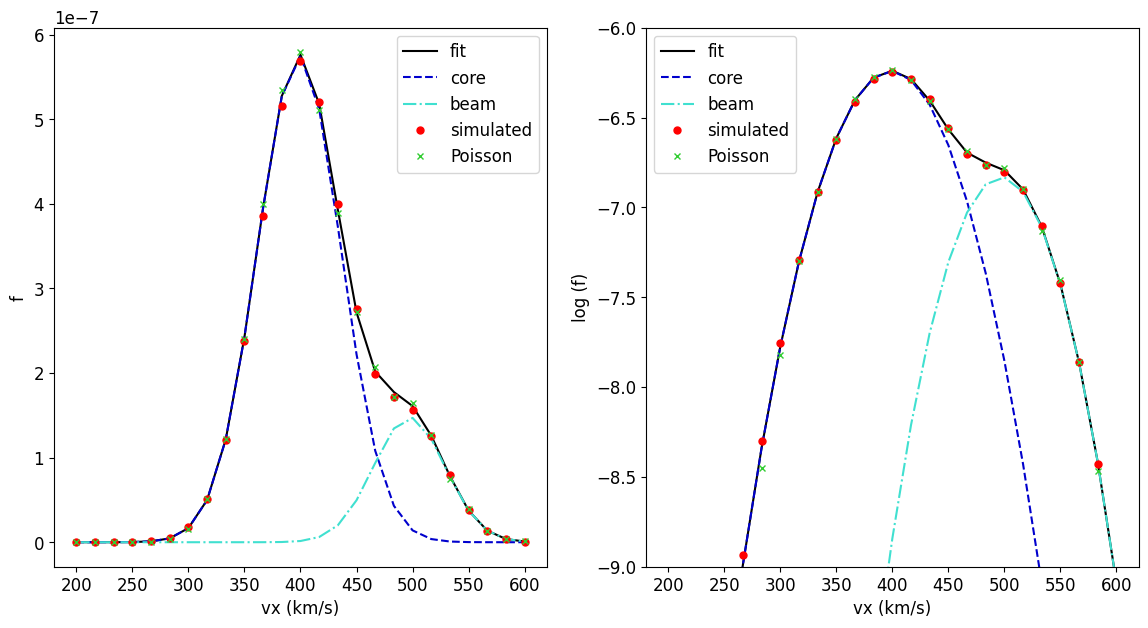

In [13]:
data_f = np.copy(vdf)
core_f = np.copy(core_fit)
beam_f = np.copy(beam_fit)
fit_f = np.copy(vdf_fit)
poisson_f = np.copy(vdf_poisson)

data_plot = np.trapezoid(np.trapezoid(data_f, axis=2), axis=1)
fit_plot = np.trapezoid(np.trapezoid(fit_f, axis=2), axis=1)
core_plot = np.trapezoid(np.trapezoid(core_f, axis=2), axis=1)
beam_plot = np.trapezoid(np.trapezoid(beam_f, axis=2), axis=1)
poisson_plot = np.trapezoid(np.trapezoid(poisson_f, axis=2), axis=1)

fig, ax = plt.subplots(ncols = 2, figsize = [14, 7])

ax[0].plot(vx*1e-3, fit_plot, color = 'black', label = 'fit')
ax[0].plot(vx*1e-3, core_plot, '--', color = 'mediumblue', label = 'core')
ax[0].plot(vx*1e-3, beam_plot, '-.',color = 'turquoise', label = 'beam')
ax[0].plot(vx*1e-3, data_plot, 'o', ms = 5, mew = 1, color = 'red', label = 'simulated')
ax[0].plot(vx*1e-3, poisson_plot, 'x', ms = 5, mew = 1, color = 'limegreen', label = 'Poisson')
ax[0].set_xlabel('vx (km/s)')
ax[0].set_ylabel('f')
ax[0].legend()

ax[1].plot(vx*1e-3, np.log10(fit_plot), color = 'black', label = 'fit')
ax[1].plot(vx*1e-3, np.log10(core_plot), '--', color = 'mediumblue', label = 'core')
ax[1].plot(vx*1e-3, np.log10(beam_plot), '-.', color = 'turquoise', label = 'beam')
ax[1].plot(vx*1e-3, np.log10(data_plot), 'o', ms = 5, mew = 1, color = 'red', label = 'simulated')
ax[1].plot(vx*1e-3, np.log10(poisson_plot), 'x', ms = 5, mew = 1, color = 'limegreen', label = 'Poisson')
ax[1].set_xlabel('vx (km/s)')
ax[1].set_ylabel('log (f)')
ax[1].set_ylim(-9, -6)
ax[1].legend()

plt.show()